<a href="https://colab.research.google.com/github/swaroop070305/TASK-TRAINING/blob/main/RNN_%26_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#RNN

In [1]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Sample sequence data
X = np.array([
    [[1], [2], [3]],
    [[2], [3], [4]],
    [[3], [4], [5]],
    [[4], [5], [6]]
])

# Target values
y = np.array([4, 5, 6, 7])

# Build the RNN model
model = Sequential([
    SimpleRNN(10, activation='tanh', input_shape=(3, 1)),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X, y, epochs=200, verbose=0)

# Test prediction
test = np.array([[[5], [6], [7]]])
prediction = model.predict(test)

print("Predicted Next Number:", prediction[0][0])
#print("Predicted Next Number:", prediction[0][1])
#print("Predicted Next Number:", prediction[0][2])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
Predicted Next Number: 3.535685


#CNN

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


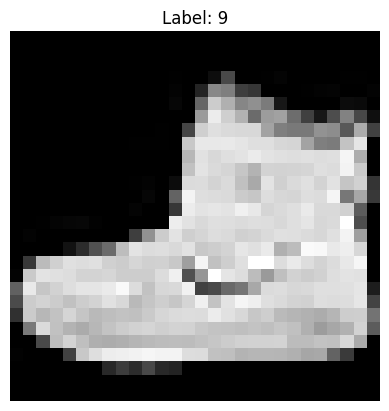

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
 445/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.6612 - loss: 0.9462

In [ ]:
# Import Libraries
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize Images
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape Images (28 x 28 x 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Display One Image
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

# Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

# Prediction
prediction = model.predict(X_test[:5])

print("Predicted Labels:")
print(prediction.argmax(axis=1))

print("Actual Labels:")